#### Impact of Hypothesis 1 violations on the (non-increasing then non-decreasing) shape of $B^*_\delta$

Hypothesis 1 requires every non-error to have a strictly higher $\kappa_f$ than every error within
the stratum, we sweep the ranking quality and measure how the shape survives.

In [1]:
%run -i ../python_scripts/nb_setup.py

In [2]:
METRIC = "FPR"
THETA_MIN, THETA_MAX = 0, 1
RANKINGS = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 2, 4, 6, 20, np.inf]
SIZES = np.arange(500, 20000, 500)
NUM_SEEDS = 15

**Hypothesis 1 violation.** Order the stratum by decreasing $\kappa_f$ and read the loss
vector $L$. Hypothesis 1 holds iff it is perfectly separated, $L^{sep}:=(0,\dots,0,1,\dots,1)$. The cost of moving $L$ onto that ideal is $\sum_i |\mathrm{cumsum}(L)_i-\mathrm{cumsum}(L^{sep})_i|$,
which counts the discordant (error, non-error) pairs: divided by $n_{ok}n_{err}$ it is the percentage of all doable (error, non-error) pairs which violate (H1).

**Bounds shape violation.** Fit the closest valley-shaped curve $b(\theta)$ to the bound path $\hat{b}(\theta)$ (isotonic
decreasing then isotonic increasing, over the best split point) and take the area between the two.
It is $0$ exactly when the path is already non-increasing then non-decreasing, and grows with the
depth and width of any peak

#### We compute approximated area between the two curves, for multiple seed, for multiple parameters ($n$,ranking intensity) values

In [3]:
rows = []
for n in SIZES:
    for ranking in tqdm(RANKINGS, desc=f"n={n}"):
        for seed in range(NUM_SEEDS):
            sim = simulate_sgp_dataset(n, ranking=ranking, seed=seed)
            b = bound_path(sim, METRIC)
            if len(b) < 3:
                continue
            cost, auc_emp, h1 = h1_transport(sim, METRIC)
            area = ushape_area(b)
            rows.append(
                {
                    "n": n,
                    "ranking": ranking,
                    "h1_cost": cost,
                    "auc_emp": auc_emp,
                    "h1": h1,
                    "u_area": area,
                    "u_area_rel": area / b.sum(),
                }
            )
res = pd.DataFrame(rows)

n=3500:  58%|█████▊    | 7/12 [00:18<00:13,  2.70s/it]


KeyboardInterrupt: 

In [ ]:
agg = res.groupby(["n", "ranking"])[["h1_cost", "h1", "u_area"]].mean()
display(agg.round(4))

h1_cost   h1  u_area
n     ranking                           
500   0.0      1.978147e+04  0.0  0.0012
      0.1      1.807060e+04  0.0  0.0019
      0.3      1.441600e+04  0.0  0.0012
      0.5      1.105227e+04  0.0  0.0008
      0.7      8.359800e+03  0.0  0.0005
...                     ...  ...     ...
19500 2.0      3.031020e+06  0.0  0.0000
      4.0      8.502107e+05  0.0  0.0000
      6.0      3.772028e+05  0.0  0.0000
      20.0     3.326680e+04  0.0  0.0000
      inf      0.000000e+00  1.0  0.0000

[468 rows x 3 columns]

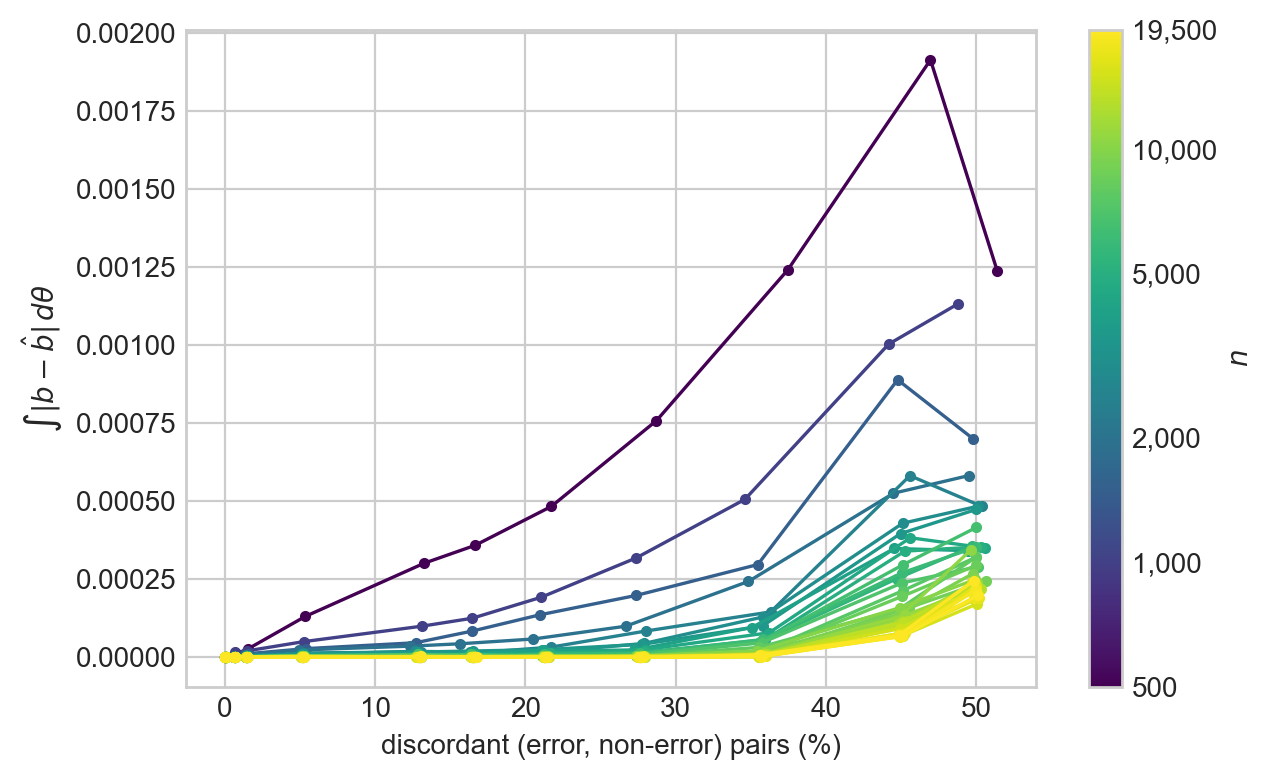

In [ ]:
ns = sorted(res.n.unique())
cnorm, cmap = LogNorm(vmin=min(ns), vmax=max(ns)), plt.cm.viridis

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(6.5, 4), dpi=200)
    for n, g in res.groupby("n"):
        m = g.groupby("ranking")[["auc_emp", "u_area"]].mean()
        m["x"] = 100 * (1 - m.auc_emp)
        m = m.sort_values("x")
        ax.plot(m.x, m.u_area, marker="o", ms=3, lw=1.2, color=cmap(cnorm(n)))
    ax.set_xlabel("discordant (error, non-error) pairs (%)")
    ax.set_ylabel(r"$\int |b - \hat{b}|\, d\theta$")
    ticks = sorted(
        {min(ns), 1000, 2000, 5000, 10000, max(ns)} & set(range(min(ns), max(ns) + 1))
    )
    cbar = fig.colorbar(ScalarMappable(norm=cnorm, cmap=cmap), ax=ax, ticks=ticks)
    cbar.ax.minorticks_off()
    cbar.ax.set_yticklabels([f"{t:,}" for t in ticks])
    cbar.set_label("$n$")
    plt.title(METRIC)
    plt.tight_layout()
    plt.show()